In [1]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import io
import hashlib
from pathlib import Path

c:\ITBA\MINICONDA\envs\TrabajoPractico_1\Lib\site-packages\albumentations\__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.7'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
import mlflow
import mlflow.pytorch

In [3]:
# Creamos el "experimento" en MLflow
mlflow.set_experiment("MLP_Clasificador_Imagenes")

<Experiment: artifact_location='file:///c:/ITBA/REDES%20NEURONALES/Tp1-Redes-Neuronales/mlruns/548689065550430374', creation_time=1779236188962, experiment_id='548689065550430374', last_update_time=1779236188962, lifecycle_stage='active', name='MLP_Clasificador_Imagenes', tags={}>

In [4]:
from torch.utils.tensorboard import SummaryWriter
import torchvision.utils as vutils

In [5]:
# Función para loguear una figura matplotlib en TensorBoard
def plot_to_tensorboard(fig, writer, tag, step):
    buf = io.BytesIO()
    fig.savefig(buf, format='png')
    buf.seek(0)
    image = Image.open(buf).convert("RGB")
    image = np.array(image)
    image = torch.tensor(image).permute(2, 0, 1) / 255.0
    writer.add_image(tag, image, global_step=step)
    plt.close(fig)

In [6]:
def log_classification_report(model, loader, writer, device, classes, step, prefix="val"):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    fig_cm, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
    ax.set_title(f'{prefix.title()} - Confusion Matrix')

    fig_path = f"confusion_matrix_{prefix}_epoch_{step}.png"
    fig_cm.savefig(fig_path)
    mlflow.log_artifact(fig_path)
    os.remove(fig_path)

    plot_to_tensorboard(fig_cm, writer, f"{prefix}/confusion_matrix", step)

    cls_report = classification_report(all_labels, all_preds, target_names=classes)
    writer.add_text(f"{prefix}/classification_report", f"<pre>{cls_report}</pre>", step)

    report_path = f"classification_report_{prefix}_epoch_{step}.txt"
    with open(report_path, "w") as f:
        f.write(cls_report)
    mlflow.log_artifact(report_path)
    os.remove(report_path)

In [7]:
# Crear directorio de logs
log_dir = "runs/mlp_experimento_1"
writer = SummaryWriter(log_dir=log_dir)

In [8]:
# Clase que le dice a PyTorch cómo leer nuestras imágenes, recorre las carpetas, asocia cada imagen con su clase, y aplica los transforms (resize, augmentations, normalización)

from pathlib import Path
from torch.utils.data import Dataset
from PIL import Image
import numpy as np

class CustomImageDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform
        
        # Clases fijas oficiales para mantener el mismo orden siempre
        self.classes = ['bcc', 'mel', 'nv']
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}
        
        # Extraemos la clase buscando el nombre de la carpeta de forma infalible
        self.labels = []
        for p in self.image_paths:
            # Path(p).parts nos da una lista con cada carpeta de la ruta
            parts = Path(p).parts
            
            folder_name = None
            for part in parts:
                if part in self.class_to_idx:
                    folder_name = part
                    break
            
            # Si por una alineación cósmica no la encuentra, usa el padre directo
            if folder_name is None:
                folder_name = Path(p).parent.name
                
            self.labels.append(self.class_to_idx[folder_name])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = np.array(Image.open(img_path).convert("RGB"))
        label = self.labels[idx]

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented["image"]

        return image, label

In [9]:
train_transform = A.Compose([
    A.Resize(64, 64), 
    
    # --- ROTACIONES ---
    A.HorizontalFlip(p=0.5),
    # A.VerticalFlip(p=0.5),
    # A.RandomRotate90(p=0.5),   
    
    # --- ILUMINACIÓN ---
    A.RandomBrightnessContrast(p=0.4), 
    
    # --- LAS DOS NUEVAS BALAS DE PLATA ---
    # A.CLAHE(p=0.3), # Resalta los bordes y texturas internas
    # A.CoarseDropout(max_holes=6, max_height=1, max_width=20, p=0.3, fill_value=0), # Simula vello
    
    A.Normalize(), 
    ToTensorV2()
])


In [10]:
# TRANSFORMS DE VAL: sin augmentations, solo resize y normalizar (no queremos modificar las imágenes de validación)

val_test_transform = A.Compose([
    A.Resize(64, 64),
    A.Normalize(),
    ToTensorV2()
])

In [11]:
# Rutas base
train_dir = Path("data/Split_smol/train")
val_dir   = Path("data/Split_smol/val")

# Leemos TRAIN completo
all_train_paths = [p for p in train_dir.glob("**/*") if p.suffix.lower() in ['.jpg', '.jpeg', '.png']]

# Reconstrucción del split VAL (igual al EDA)
def get_class(x): return x.parent.name
valid_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

files_val = []
for x in val_dir.rglob('*'):
    if x.is_file() and x.suffix.lower() in valid_extensions:
        try:
            with Image.open(x) as img:
                files_val.append((x, get_class(x), img.size, img.mode))
        except Exception:
            pass

df_val_completo = pd.DataFrame(files_val, columns=["path", "class", "resolution", "mode"])
df_val_completo = df_val_completo.sort_values(by="path").reset_index(drop=True)

# Split val → val (50%) + test (50%), por clase, reproducible
np.random.seed(42)
df_test = df_val_completo.groupby('class', group_keys=False).apply(
    lambda x: x.sample(frac=0.5, random_state=42)
)
df_val_recortado = df_val_completo.drop(df_test.index).reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

all_val_paths  = [Path(p) for p in df_val_recortado['path'].tolist()]
all_test_paths = [Path(p) for p in df_test['path'].tolist()]

# Hashes de TRAIN para filtrar leakage
train_hashes = {}
for p in all_train_paths:
    with open(p, "rb") as f:
        file_hash = hashlib.md5(f.read()).hexdigest()
    train_hashes[file_hash] = p.name

# Filtrar TRAIN: foto negra + duplicado interno
foto_negra_train        = "ISIC_0031430.jpg"
duplicado_interno_train = "ISIC_0031039.jpg"
train_image_paths = [
    str(p) for p in all_train_paths
    if p.name != foto_negra_train and p.name != duplicado_interno_train
]

# Filtrar VAL contra TRAIN
val_image_paths = []
for p in all_val_paths:
    with open(p, "rb") as f:
        file_hash = hashlib.md5(f.read()).hexdigest()
    if file_hash not in train_hashes:
        val_image_paths.append(str(p))

# Filtrar TEST contra TRAIN
test_image_paths = []
for p in all_test_paths:
    with open(p, "rb") as f:
        file_hash = hashlib.md5(f.read()).hexdigest()
    if file_hash not in train_hashes:
        test_image_paths.append(str(p))

print(f"Train: {len(train_image_paths)} | Val: {len(val_image_paths)} | Test: {len(test_image_paths)}")

C:\Users\Sofia\AppData\Local\Temp\ipykernel_18244\3496033778.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_test = df_val_completo.groupby('class', group_keys=False).apply(


Train: 695 | Val: 73 | Test: 75


In [12]:
# DataLoaders — usan paths filtrados, limpios de leakage
from torch.utils.data import DataLoader

# Creamos los datasets usando las listas de paths filtradas por hash
train_dataset = CustomImageDataset(train_image_paths, transform=train_transform)
val_dataset   = CustomImageDataset(val_image_paths,   transform=val_test_transform)
test_dataset  = CustomImageDataset(test_image_paths,  transform=val_test_transform)

# Creamos los DataLoaders oficiales
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size)

print(f"DataLoaders listos - Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

KeyError: 'Actinic keratosis'

In [ ]:
# MLP: Flatten → 512 → BN → ReLU → Dropout(0.25) → 128 → BN → ReLU → salida
class MLPClassifier(nn.Module):
    def __init__(self, num_classes, input_size=64*64*3):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),

            # --- CAPA 1 ---
            nn.Linear(input_size, 512),
            # nn.BatchNorm1d(512),
            nn.ReLU(),
            # nn.Dropout(0.25),

            # --- CAPA 2 ---
            nn.Linear(512, 128),
            # nn.BatchNorm1d(128),
            nn.ReLU(),
            # nn.Dropout(0),

            # --- SALIDA ---
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(train_dataset.classes)
model = MLPClassifier(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-3)




In [ ]:
def evaluate(model, loader, epoch=None, prefix="val"):
    model.eval()  # <- primero esto, siempre
    model.to(device) # 💡 PARCHE 1: Aseguramos que el modelo esté en la GPU/CPU correcta
    
    # 💡 PARCHE 2: Usamos las clases fijas ['bcc', 'mel', 'nv'] que definimos en la Celda 7
    clases_oficiales = ['bcc', 'mel', 'nv']
    log_classification_report(model, loader, writer, device, clases_oficiales, step=epoch, prefix=prefix)
    
    correct, total, loss_sum = 0, 0, 0.0
    all_preds, all_labels = [], []

    # 💡 PARCHE 3: Nos aseguramos de que el criterion global conozca el dispositivo por si acaso
    if 'criterion' in globals():
        global criterion
        criterion = criterion.to(device)

    with torch.no_grad():
        for i, (images, labels) in enumerate(loader):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            loss_sum += loss.item()
            correct  += (preds == labels).sum().item()
            total    += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            if i == 0 and epoch is not None:
                img_grid = vutils.make_grid(images[:8].cpu(), normalize=True)
                writer.add_image(f"{prefix}/images", img_grid, global_step=epoch)

    acc      = 100.0 * correct / total
    avg_loss = loss_sum / len(loader)

    if epoch is not None:
        writer.add_scalar(f"{prefix}/loss",     avg_loss, epoch)
        writer.add_scalar(f"{prefix}/accuracy", acc,      epoch)

    return avg_loss, acc

Epoch 1/10: 100%|██████████| 22/22 [00:11<00:00,  1.93it/s]


ValueError: The number of FixedLocator locations (8), usually from a call to set_ticks, does not match the number of labels (9).

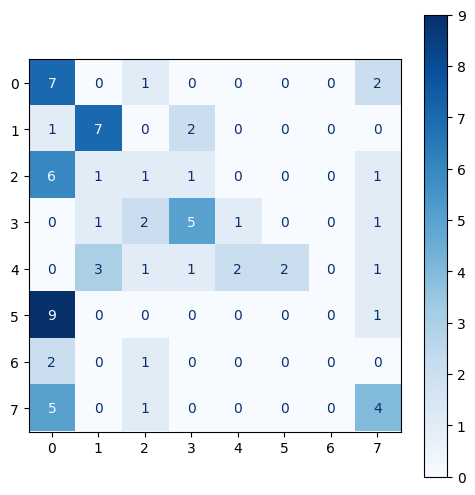

In [ ]:
n_epochs = 10
with mlflow.start_run():
    mlflow.log_params({
        "model":      "MLPClassifier",
        "input_size": 64*64*3,
        "batch_size": batch_size,
        "lr":         0.001,
        "weight_decay": 1e-3,
        "epochs":     n_epochs,
        "optimizer":  "Adam",
        "loss_fn":    "CrossEntropyLoss",
        # "dropout":    0.25,
        "train_dir":  str(train_dir),
        "val_dir":    str(val_dir),
        "augmentations": "HFlip, BrightnessContrast" # CLAHE, CoarseDropout,  VFlip, Rotate90,
    })

    for epoch in range(n_epochs):
        model.train()
        running_loss = 0.0
        correct, total = 0, 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs}"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc  = 100.0 * correct / total
        val_loss, val_acc = evaluate(model, val_loader, epoch=epoch, prefix="val")

        print(f"Epoch {epoch+1}:")
        print(f"  Train Loss: {train_loss:.4f}, Accuracy: {train_acc:.2f}%")
        print(f"  Val   Loss: {val_loss:.4f}, Accuracy: {val_acc:.2f}%")

        writer.add_scalar("train/loss",     train_loss, epoch)
        writer.add_scalar("train/accuracy", train_acc,  epoch)

        mlflow.log_metrics({
            "train_loss":     train_loss,
            "train_accuracy": train_acc,
            "val_loss":       val_loss,
            "val_accuracy":   val_acc
        }, step=epoch)

    torch.save(model.state_dict(), "mlp_model.pth")
    mlflow.log_artifact("mlp_model.pth")
    mlflow.pytorch.log_model(model, artifact_path="pytorch_model")
    print("Modelo guardado como 'mlp_model.pth'")

In [ ]:
!tensorboard --logdir=runs/mlp_experimento_1

^C
